Dataset Information :The dataset consists of raw gaze coordinates (x,y) of 24 participants while they were performing desktop activities – Read All the activities were 5 minutes long. The eye movements were recorded using a desktop mounted Tobii X2-30 eye tracker and Tobii Pro Studio software.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#Read and view the data set
df = pd.read_csv('/content/gdrive/MyDrive/ALS_READ_DATA.csv')
df.head()

,participant,set,activity,x,y,timestamp
0,P11,B,READ,1060,521,0
1,P11,B,READ,1061,487,24
2,P11,B,READ,1086,475,52
3,P11,B,READ,1070,482,82
4,P11,B,READ,1078,473,113


In [ ]:
#checking the missing data
df.isnull().any()

,0
participant,False
set,False
activity,False
x,False
y,False
timestamp,False


In [ ]:
print(df[['x', 'y']].describe()) #Describing and checking the data properties

                 x            y
count  7833.000000  7833.000000
mean    906.104685   410.038810
std     155.679646   159.475824
min      93.000000 -1077.000000
25%     775.000000   290.000000
50%     882.000000   393.000000
75%    1033.000000   509.000000
max    2010.000000  1359.000000


Key Points
Descriptive Analysis: Provides insights into how the gaze data varies, with key statistical measures.
Time Series Analysis: Helps you understand the dynamics of how gaze position changes over time.
Visualization: Both distribution plots and path visualizations can provide useful insights into the nature of the gaze.

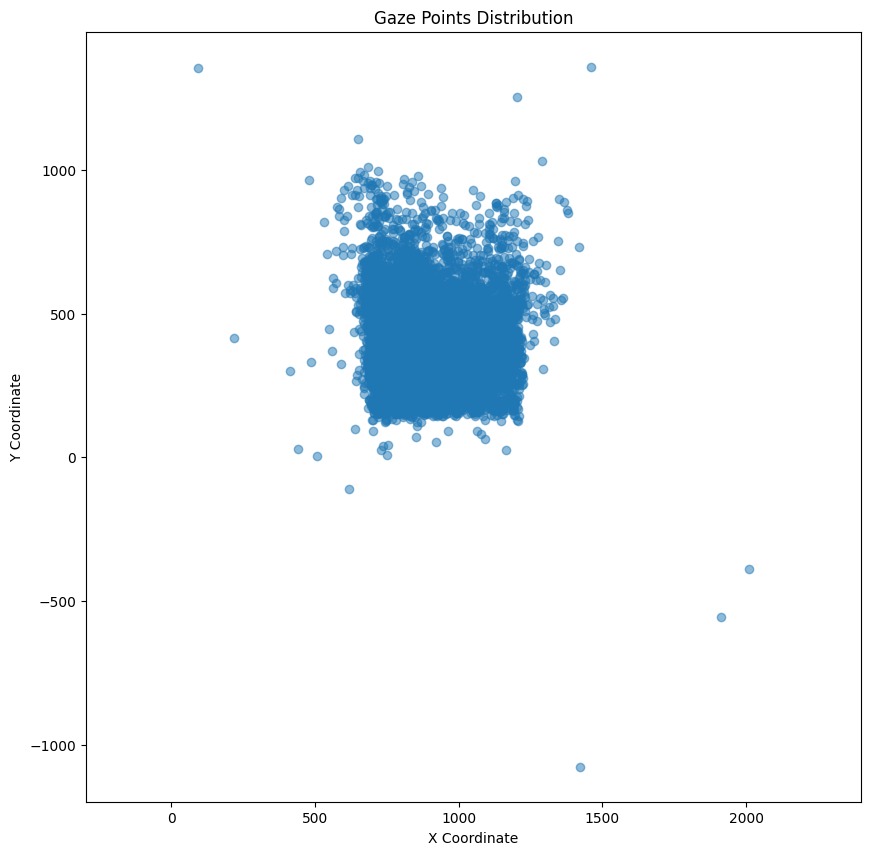

In [ ]:
plt.figure(figsize=(10, 10))  #Visualization of Eyes Gaze Points
plt.scatter(df['x'], df['y'], alpha=0.5)
plt.title('Gaze Points Distribution')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')  # Ensuring the aspect ratio is equal
plt.show()

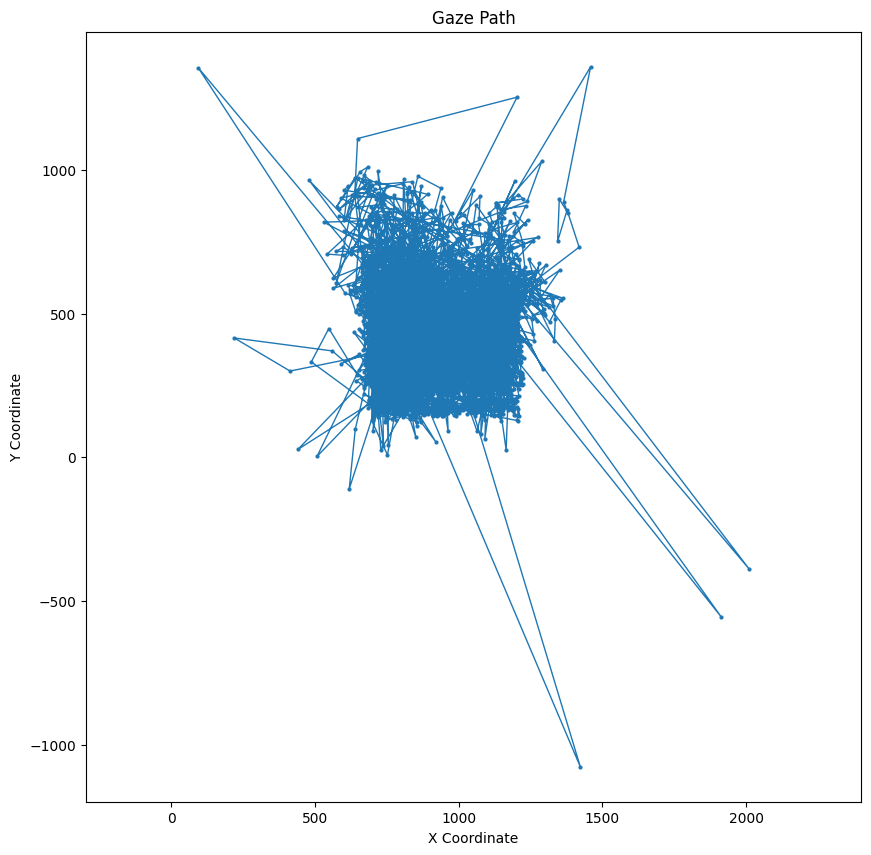

In [ ]:
# Analyzing movment paths, visualizing the gaze paths (segmentation)
plt.figure(figsize=(10, 10))
plt.plot(df['x'], df['y'], marker='o', markersize=2, linewidth=1)
plt.title('Gaze Path')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.axis('equal')  # The aspect ratio must be  equal
plt.show()

In [ ]:
# Create distance from the center of the screen (assuming 1920x1080 resolution)
df['screen_center_x'] = df['x'] - 960  # Adjust based on screen size
df['screen_center_y'] = df['y'] - 540  # Adjust based on screen size
df['distance_from_center'] = (df['screen_center_x']**2 + df['screen_center_y']**2)**0.5

In [ ]:
df

,participant,set,activity,x,y,timestamp,screen_center_x,screen_center_y,distance_from_center
0,P11,B,READ,1060,521,0,100,-19,101.788997
1,P11,B,READ,1061,487,24,101,-53,114.061387
2,P11,B,READ,1086,475,52,126,-65,141.777995
3,P11,B,READ,1070,482,82,110,-58,124.354332
4,P11,B,READ,1078,473,113,118,-67,135.694510
...,...,...,...,...,...,...,...,...,...
7828,P11,B,READ,709,688,299875,-251,148,291.384626
7829,P11,B,READ,715,668,299903,-245,128,276.421779
7830,P11,B,READ,698,690,299934,-262,150,301.900646
7831,P11,B,READ,707,645,299962,-253,105,273.923347


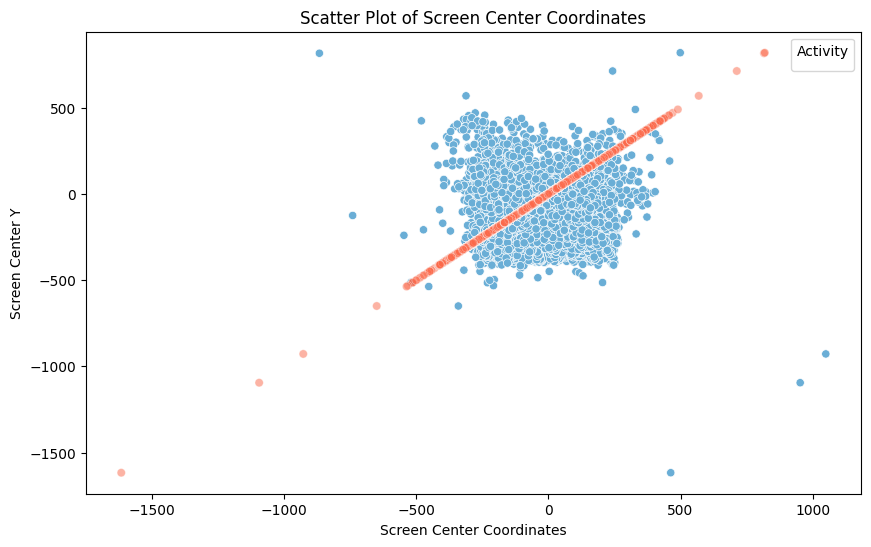

In [ ]:
plt.figure(figsize=(10, 6))

# First plot: screen_center_x
sns.scatterplot(data=df, x='screen_center_x', y='screen_center_y', hue='activity', palette='Blues', legend=False)

# Second plot: screen_center_y
sns.scatterplot(data=df, x='screen_center_y', y='screen_center_y', hue='activity', palette='Reds', legend=False, alpha=0.5)

# Set the title and labels
plt.title('Scatter Plot of Screen Center Coordinates')
plt.xlabel('Screen Center Coordinates')
plt.ylabel('Screen Center Y')

# Show the legend for activities
plt.legend(title='Activity')

# Show the plot
plt.show() #user interaction, usability testing, design optimization, understanding user preference

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import joblib



df['timestamp'] = df['timestamp'] / 1000  # Convert milliseconds to seconds

# Select features and target variable
features = df[['timestamp', 'x', 'y', 'screen_center_x', 'screen_center_y']]
target = df['distance_from_center']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the training data, then transform the test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize the Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)


# Save the Model and the Scaler
joblib.dump(model, 'random_forest_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [ ]:
#Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred )
mse = mean_squared_error(y_test, y_pred )
r2 = r2_score(y_test, y_pred )

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}, MSE: {mse},  R²: {r2},rmse")
rmse



MAE: 2.7377279261887493, MSE: 563.3236299592254,  R²: 0.952554047404061,rmse


23.734439743950677

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, features, target, scoring='neg_mean_squared_error', cv=5)
print(f"Cross-validated MSE: {-scores.mean()}")

Cross-validated MSE: 253.6968285398187


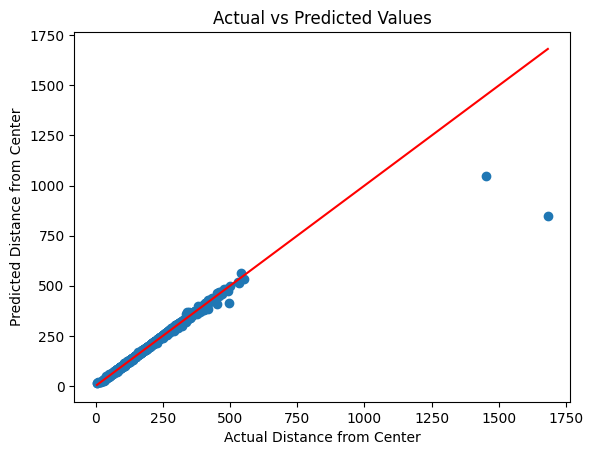

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Distance from Center")
plt.ylabel("Predicted Distance from Center")
plt.title("Actual vs Predicted Values")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')  # 45-degree line
plt.show()

NEW PREDICTION

In [ ]:
import os

# Create sample data and save it to 'data/new_data.csv'
sample_data = {
    'timestamp': np.random.randint(1609459200000, 1640995200000, size=100),  # Random timestamps in milliseconds (2021)
    'x': np.random.rand(100),
    'y': np.random.rand(100),
    'screen_center_x': np.random.rand(100),
    'screen_center_y': np.random.rand(100),
}

# Create a DataFrame
new_data_df = pd.DataFrame(sample_data)

# Ensure the 'data' directory exists
os.makedirs('data', exist_ok=True)

# Save the DataFrame to a CSV file
new_data_path = 'data/new_data.csv'
new_data_df.to_csv(new_data_path, index=False)

# Load new data for predictions
new_data = pd.read_csv(new_data_path)
new_data['timestamp'] = new_data['timestamp'] / 1000  # Convert milliseconds to seconds

# Assume model and scaler are already defined and loaded previously
# Prepare new features
new_features = new_data[['timestamp', 'x', 'y', 'screen_center_x', 'screen_center_y']]

# Load the saved scaler and scale the new features
scaler = joblib.load('scaler.pkl')
new_features_scaled = scaler.transform(new_features)

# Load the saved model and make predictions on new data
model = joblib.load('random_forest_model.pkl')
new_predictions = model.predict(new_features_scaled)

# Output predictions
new_data['predicted_distance_from_center'] = new_predictions
print(new_data[['timestamp', 'x', 'y', 'screen_center_x', 'screen_center_y', 'predicted_distance_from_center']])


       timestamp         x         y  screen_center_x  screen_center_y  \
0   1.615139e+09  0.157022  0.342051         0.590103         0.655516   
1   1.609892e+09  0.322765  0.579932         0.533257         0.857893   
2   1.627598e+09  0.608234  0.028298         0.771600         0.137982   
3   1.634902e+09  0.564789  0.923084         0.528385         0.444195   
4   1.636784e+09  0.753489  0.419312         0.858074         0.110645   
..           ...       ...       ...              ...              ...   
95  1.631378e+09  0.197687  0.683915         0.641586         0.394266   
96  1.622881e+09  0.800489  0.939521         0.554269         0.288786   
97  1.610114e+09  0.061276  0.762121         0.836914         0.612444   
98  1.636577e+09  0.030018  0.077641         0.006109         0.258534   
99  1.612940e+09  0.053590  0.933726         0.868133         0.697093   

    predicted_distance_from_center  
0                       364.386136  
1                       364.386136  


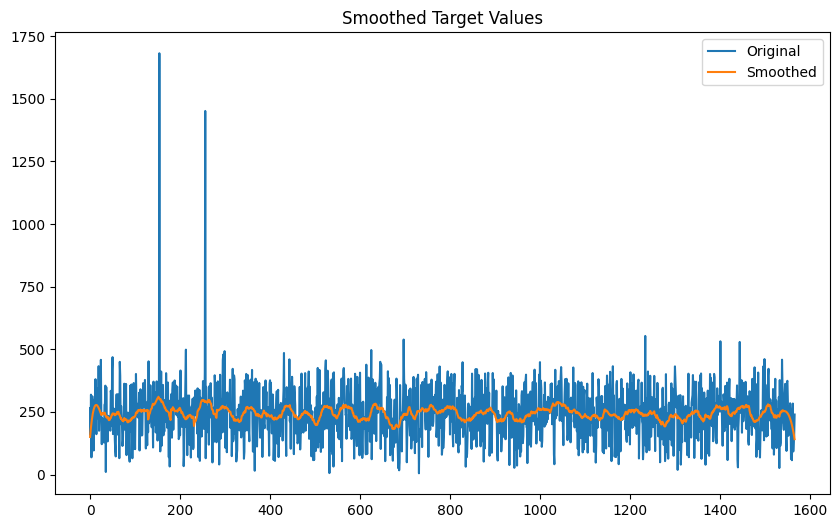

In [ ]:
from scipy.stats import norm
import plotly.express as px
from scipy.signal import savgol_filter

# Smoothing using Savitzky-Golay Filter
# Apply the filter to the target values
y_test_smooth = savgol_filter(y_test.values, 51, 3)

# Plot the smoothed target values
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Original')
plt.plot(y_test_smooth, label='Smoothed')
plt.title('Smoothed Target Values')
plt.legend()
plt.show()

ANOMALY CHECK

In [ ]:
from sklearn.datasets import make_moons, make_blobs
from sklearn.covariance import EllipticEnvelope


In [ ]:
X = df[['x','y']]

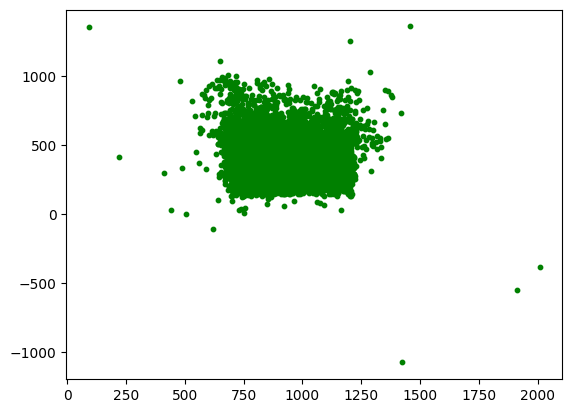

In [ ]:
plt.scatter(X.values[:, 0], X.values[:, 1], marker="o", s=10, color='green')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

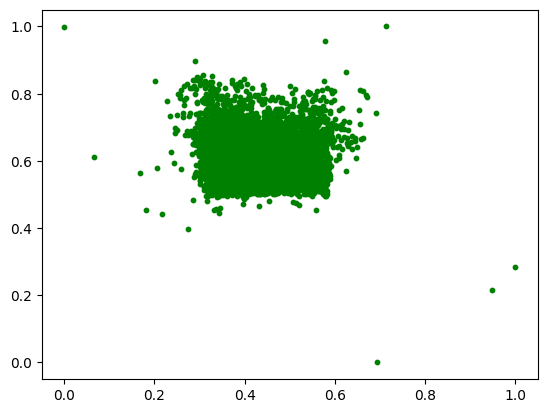

In [ ]:
plt.scatter(X_norm[:, 0], X_norm[:, 1], marker="o", s=10, color='green')

In [ ]:
from sklearn.covariance import EllipticEnvelope
elliptic_envelope_algorithm = EllipticEnvelope(contamination=0.05)

elliptic_envelope_algorithm.fit(X_norm)
elliptic_envelope_y_pred = elliptic_envelope_algorithm.predict(X_norm)

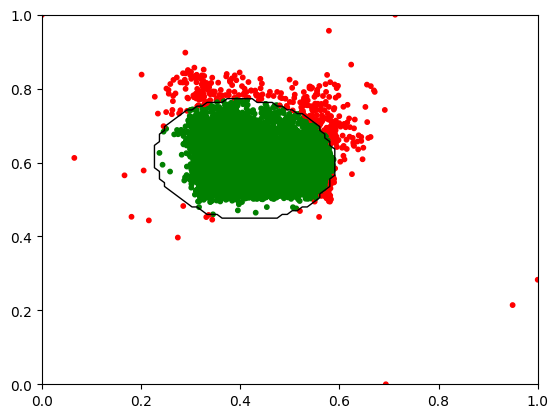

In [ ]:
xx, yy = np.meshgrid(np.linspace(0, 1, 100), np.linspace(0, 1, 100))
Z = elliptic_envelope_algorithm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
colors = np.array(['red', 'green'])

plt.scatter(X_norm[:, 0], X_norm[:, 1], s=10, color=colors[(elliptic_envelope_y_pred + 1) // 2])
plt.contour(xx, yy, Z, levels=[0], linewidths=1, colors="black")

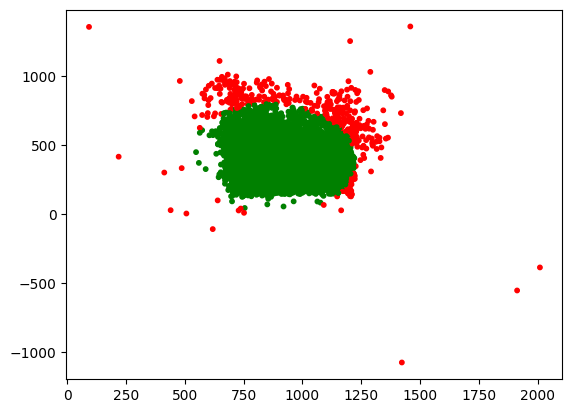

In [ ]:
plt.scatter(X.values[:, 0], X.values[:, 1], s=10, color=colors[(elliptic_envelope_y_pred + 1) // 2])

In [ ]:
xx_reshaped = xx.reshape(xx.shape[0]*xx.shape[1])
yy_reshaped = yy.reshape(yy.shape[0]*yy.shape[1])
points = np.c_[xx_reshaped, yy_reshaped]
print(points.shape)

(10000, 2)


In [ ]:
points_inv_transformed = scaler.inverse_transform(points)

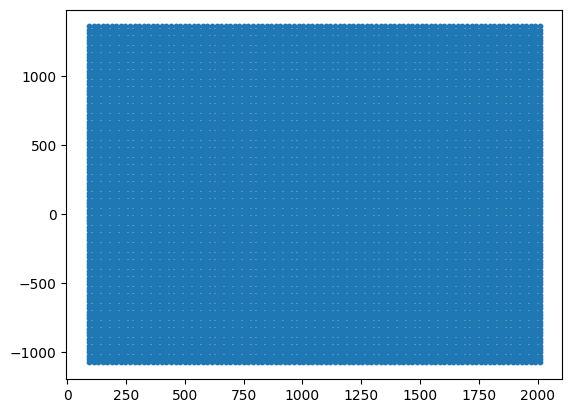

In [ ]:
plt.scatter(points_inv_transformed[:, 0], points_inv_transformed[:, 1], s=10)

In [ ]:
xx_inv_transformed = points_inv_transformed[:, 0]
xx_original_scale = xx_inv_transformed.reshape(xx.shape)
yy_inv_transformed = points_inv_transformed[:, 1]
yy_original_scale = yy_inv_transformed.reshape(yy.shape)

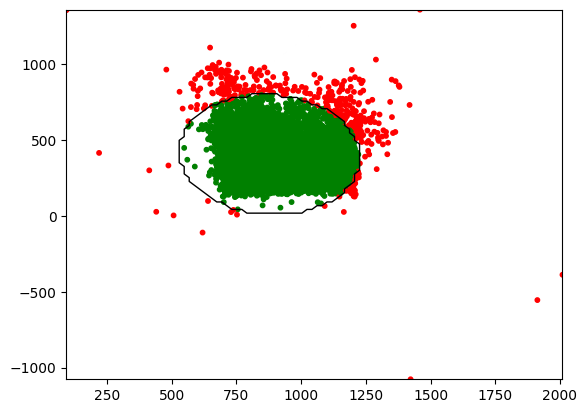

In [ ]:
plt.scatter(X.values[:, 0], X.values[:, 1], s=10, color=colors[(elliptic_envelope_y_pred + 1) // 2])
plt.contour(xx_original_scale, yy_original_scale, Z, levels=[0], linewidths=1, colors="black")

In [ ]:
X = df[['screen_center_x','screen_center_y']]

In [ ]:
plt.scatter(X.values[:, 0], X.values[:, 1], marker="o", s=10, color='green')

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_norm = scaler.fit_transform(X)

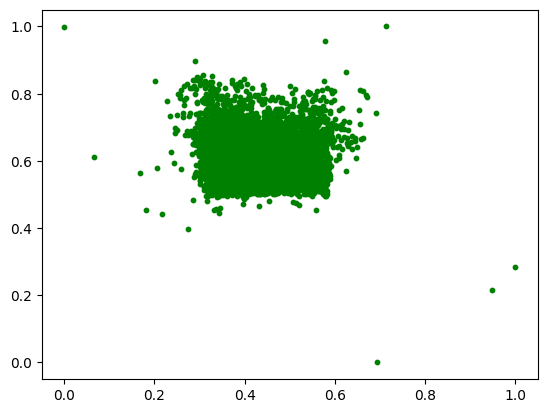

In [ ]:
plt.scatter(X_norm[:, 0], X_norm[:, 1], marker="o", s=10, color='green')

In [ ]:
from sklearn.covariance import EllipticEnvelope
elliptic_envelope_algorithm = EllipticEnvelope(contamination=0.05)

elliptic_envelope_algorithm.fit(X_norm)
elliptic_envelope_y_pred = elliptic_envelope_algorithm.predict(X_norm)